# Yes or No? Classifying Term Deposit Subscriptions using Random Forest
**Author: Aiden Liu**

---

This project applies a **Random Forest classifier** to the UCI Bank Marketing dataset to predict whether a client will subscribe to a term deposit (`yes`/`no`). The framework covers:

1. Exploratory data inspection
2. Data cleaning & feature removal
3. Class imbalance correction (upsampling)
4. Decision Tree baseline model
5. Random Forest model & feature importance
6. Partial Dependence Plots (PDPs) for top features
7. Confusion matrix & ROC/AUC evaluation
8. Actionable business insights

## Variable Description

| Variable | Description |
|---|---|
| `age` | Client age |
| `job` | Type of job (categorical) |
| `marital` | Marital status |
| `education` | Education level |
| `default` | Has credit in default? |
| `balance` | Average yearly balance (€) |
| `housing` | Has housing loan? |
| `loan` | Has personal loan? |
| `contact` | Contact communication type |
| `day` | Last contact day of month |
| `month` | Last contact month |
| `duration` | Last contact duration (seconds) |
| `campaign` | Number of contacts this campaign |
| `pdays` | Days since last contact in previous campaign (-1 = never) |
| `previous` | Contacts before this campaign |
| `poutcome` | Outcome of previous campaign |
| `y` | **Target:** subscribed a term deposit? |

## 1. Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score, ConfusionMatrixDisplay
)
from sklearn.inspection import PartialDependenceDisplay
from sklearn.utils import resample

import joblib  # for saving the model

print("All libraries loaded successfully.")

All libraries loaded successfully.


## 2. Reading in the Data

In [2]:
bank_data = pd.read_csv("bank.csv", sep=";")

print(f"Shape: {bank_data.shape}")
bank_data.head()

Shape: (4521, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


### Inspecting variable types

In [3]:
bank_data.dtypes

age          int64
job            str
marital        str
education      str
default        str
balance      int64
housing        str
loan           str
contact        str
day          int64
month          str
duration     int64
campaign     int64
pdays        int64
previous     int64
poutcome       str
y              str
dtype: object

### Check for missing values

In [4]:
print("Any NaN values?", bank_data.isnull().values.any())
bank_data.isnull().sum()

Any NaN values? False


age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

No explicit NaN values, but some columns contain `'unknown'` strings which need handling.

## 3. Data Cleaning

### Remove rows with `'unknown'` in key categorical columns

In [5]:
cols_to_clean = ['contact', 'job', 'marital', 'education', 'loan', 'month']

adj_bank_data = bank_data.copy()
for col in cols_to_clean:
    if col in adj_bank_data.columns:
        adj_bank_data = adj_bank_data[adj_bank_data[col] != 'unknown']

print(f"Rows after removing unknowns: {len(adj_bank_data)} (was {len(bank_data)})")

Rows after removing unknowns: 3064 (was 4521)


### Inspect `poutcome` — largely unknown

In [6]:
print("Count of 'unknown' in poutcome (original data):",
      (bank_data['poutcome'] == 'unknown').sum())

Count of 'unknown' in poutcome (original data): 3705


### Inspect `pdays` — mostly -1 (client not previously contacted)

In [ ]:
print("Count of -1 in pdays (original data):",
      (bank_data['pdays'] == -1).sum())

### Drop low-utility columns

In [7]:
# Drop poutcome (mostly unknown), day (day of month), month, pdays (mostly -1)
cols_to_drop = ['poutcome', 'day', 'month', 'pdays']
adj_bank_data = adj_bank_data.drop(columns=[c for c in cols_to_drop if c in adj_bank_data.columns])

print(f"Remaining columns ({len(adj_bank_data.columns)}): {list(adj_bank_data.columns)}")

Remaining columns (13): ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'duration', 'campaign', 'previous', 'y']


## 4. Class Imbalance Check

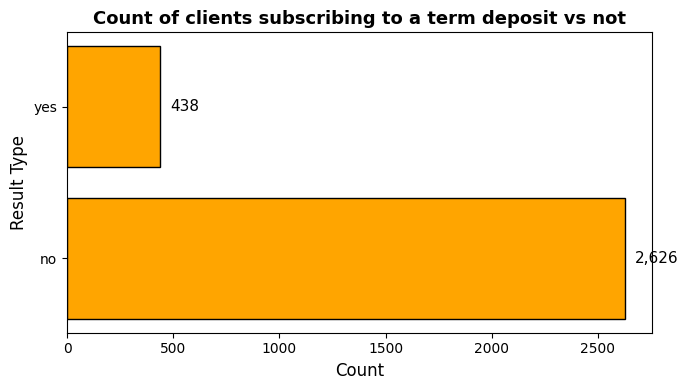

y
no     2626
yes     438
Name: count, dtype: int64


In [9]:
fig, ax = plt.subplots(figsize=(7, 4))

counts = adj_bank_data['y'].value_counts()
bars = ax.barh(counts.index, counts.values, color='orange', edgecolor='black')

# Annotate bar values
for bar, val in zip(bars, counts.values):
    ax.text(val + 50, bar.get_y() + bar.get_height() / 2,
            f'{val:,}', va='center', fontsize=11)

ax.set_xlabel("Count", fontsize=12)
ax.set_ylabel("Result Type", fontsize=12)
ax.set_title("Count of clients subscribing to a term deposit vs not",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(counts)

The dataset is **massively imbalanced**: `no` is the majority class, `yes` is the minority class. We upsample the minority class to balance it before training.

## 5. Upsampling the Minority Class

In [10]:
majority = adj_bank_data[adj_bank_data['y'] == 'no']
minority = adj_bank_data[adj_bank_data['y'] == 'yes']

minority_upsampled = resample(
    minority,
    replace=True,
    n_samples=len(majority),
    random_state=42
)

balanced_data = pd.concat([majority, minority_upsampled])

print("Balanced class distribution:")
print(balanced_data['y'].value_counts())

Balanced class distribution:
y
no     2626
yes    2626
Name: count, dtype: int64


## 6. Preprocessing & Train/Test Split

In [11]:
# One-hot encode all categorical variables (drop_first avoids multicollinearity)
balanced_encoded = pd.get_dummies(balanced_data, drop_first=True)

# Identify target column — after get_dummies 'y_yes' is created (y_no is dropped)
target_col = 'y_yes'

X = balanced_encoded.drop(columns=[target_col])
y = balanced_encoded[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")
print("\nTraining class balance:")
print(y_train.value_counts())

Training samples : 3676
Test samples     : 1576

Training class balance:
y_yes
True     1838
False    1838
Name: count, dtype: int64


## 7. Baseline — Decision Tree Classifier

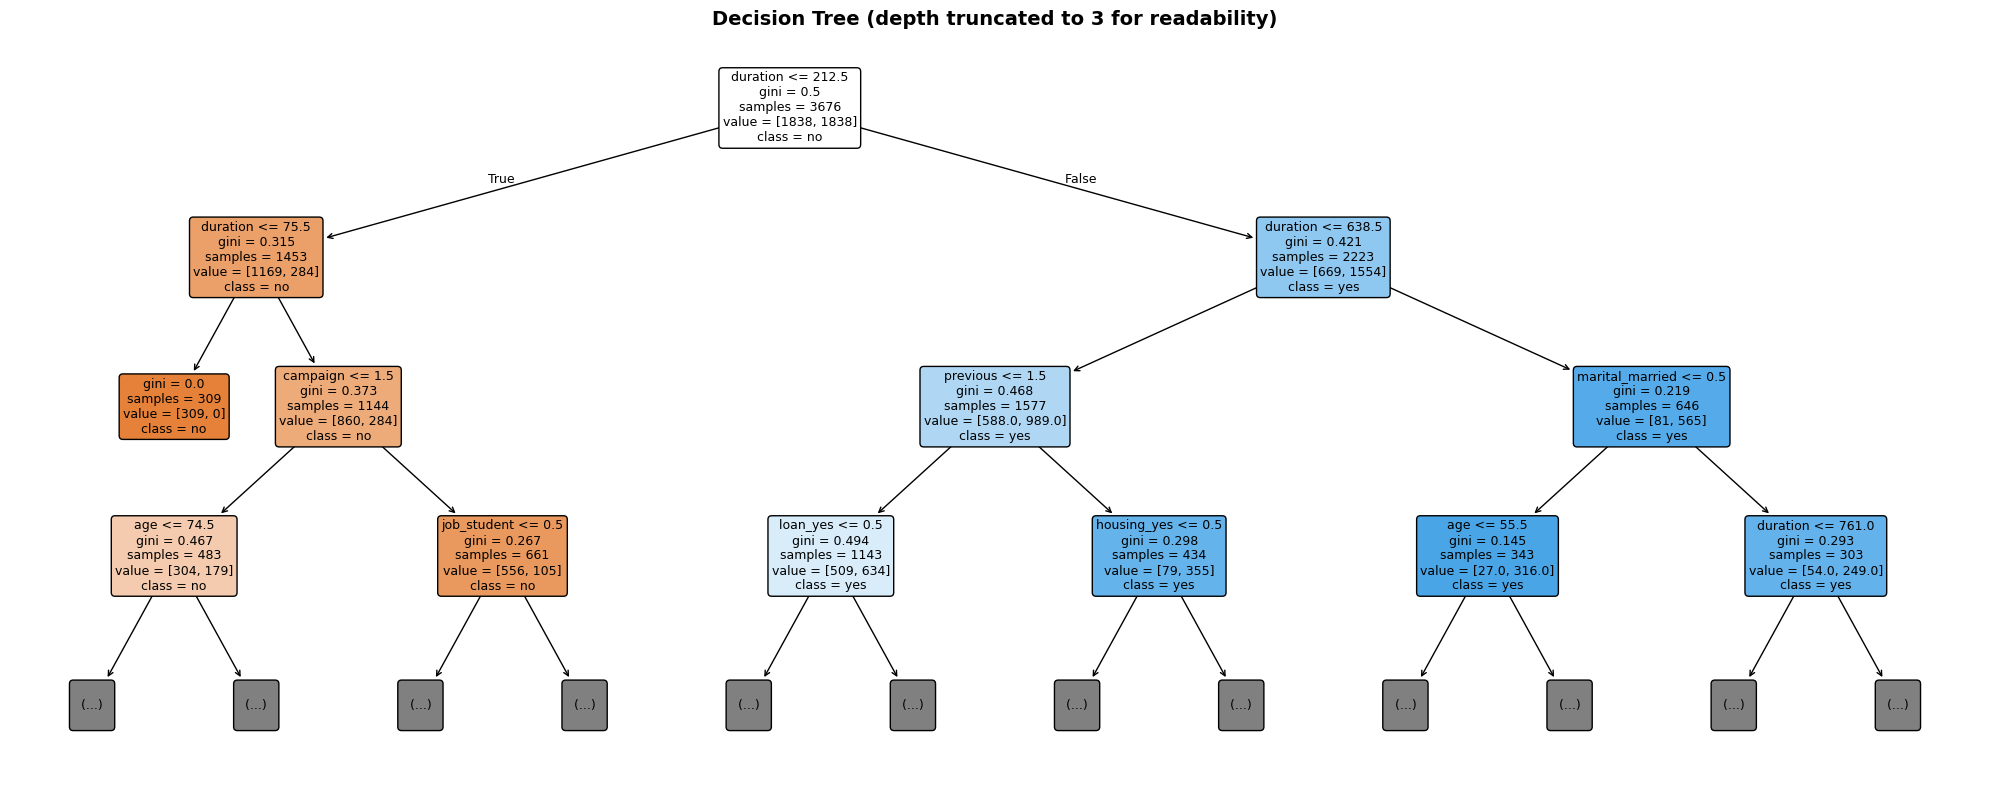

In [12]:
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)

# Visualise (truncated for readability)
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    tree_model, max_depth=3,
    feature_names=X.columns,
    class_names=['no', 'yes'],
    filled=True, rounded=True,
    fontsize=9, ax=ax
)
ax.set_title("Decision Tree (depth truncated to 3 for readability)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Decision Tree — Confusion Matrix & Classification Report

=== Decision Tree Classification Report ===
              precision    recall  f1-score   support

      no (0)       0.99      0.87      0.93       788
     yes (1)       0.89      0.99      0.94       788

    accuracy                           0.93      1576
   macro avg       0.94      0.93      0.93      1576
weighted avg       0.94      0.93      0.93      1576



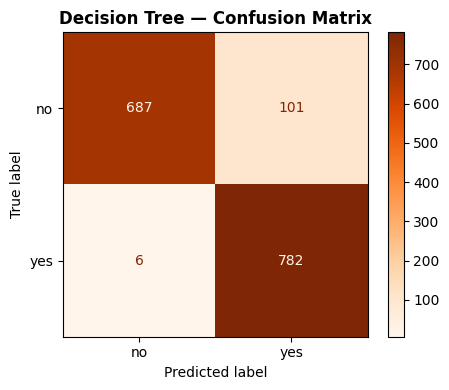

In [13]:
tree_preds = tree_model.predict(X_test)

print("=== Decision Tree Classification Report ===")
print(classification_report(y_test, tree_preds, target_names=['no (0)', 'yes (1)']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, tree_preds,
    display_labels=['no', 'yes'],
    cmap='Oranges', ax=ax
)
ax.set_title("Decision Tree — Confusion Matrix", fontweight='bold')
plt.tight_layout()
plt.show()

The Decision Tree provides a reasonable baseline, but we can do better with a **Random Forest**.

Random Forest:
- Combines many decision trees to reduce overfitting
- Handles large datasets and mixed feature types well
- Requires no normalisation or standardisation
- Provides reliable feature importance estimates

## 8. Random Forest — Full Model

In [14]:
rf_model = RandomForestClassifier(n_estimators=500, random_state=42, oob_score=True)
rf_model.fit(X_train, y_train)

print(f"OOB Score (accuracy): {rf_model.oob_score_:.4f}")
print(f"Approximate OOB Error Rate: {1 - rf_model.oob_score_:.4f}")

OOB Score (accuracy): 0.9573
Approximate OOB Error Rate: 0.0427


### OOB Error Rate over Number of Trees

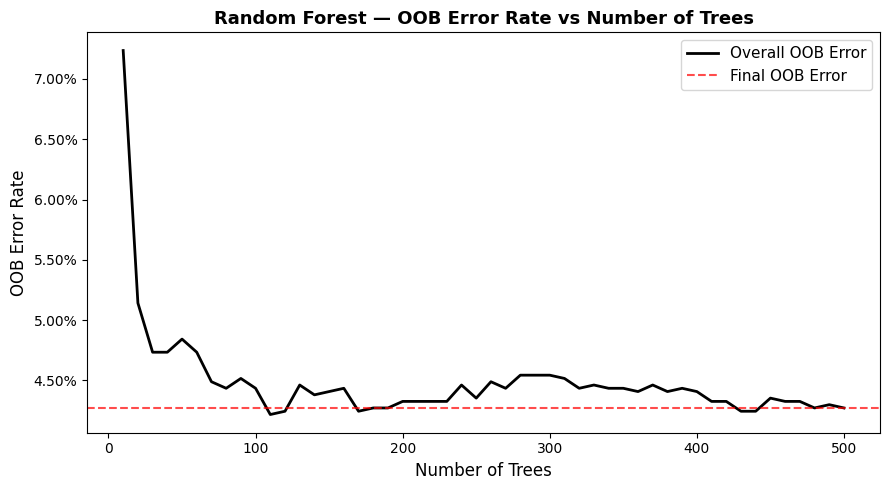

In [15]:
# Track OOB error as a function of number of trees
rf_staged = RandomForestClassifier(
    n_estimators=500, warm_start=True,
    oob_score=True, random_state=42
)

oob_errors = []
tree_counts = range(10, 501, 10)

for n in tree_counts:
    rf_staged.set_params(n_estimators=n)
    rf_staged.fit(X_train, y_train)
    oob_errors.append(1 - rf_staged.oob_score_)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(list(tree_counts), oob_errors, color='black', lw=2, label='Overall OOB Error')
ax.axhline(1 - rf_model.oob_score_, color='red', linestyle='--', alpha=0.7, label='Final OOB Error')
ax.set_xlabel("Number of Trees", fontsize=12)
ax.set_ylabel("OOB Error Rate", fontsize=12)
ax.set_title("Random Forest — OOB Error Rate vs Number of Trees", fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout()
plt.show()

The OOB error stabilises as the number of trees grows, showing the forest has enough trees to generalise effectively.

## 9. Feature Importance

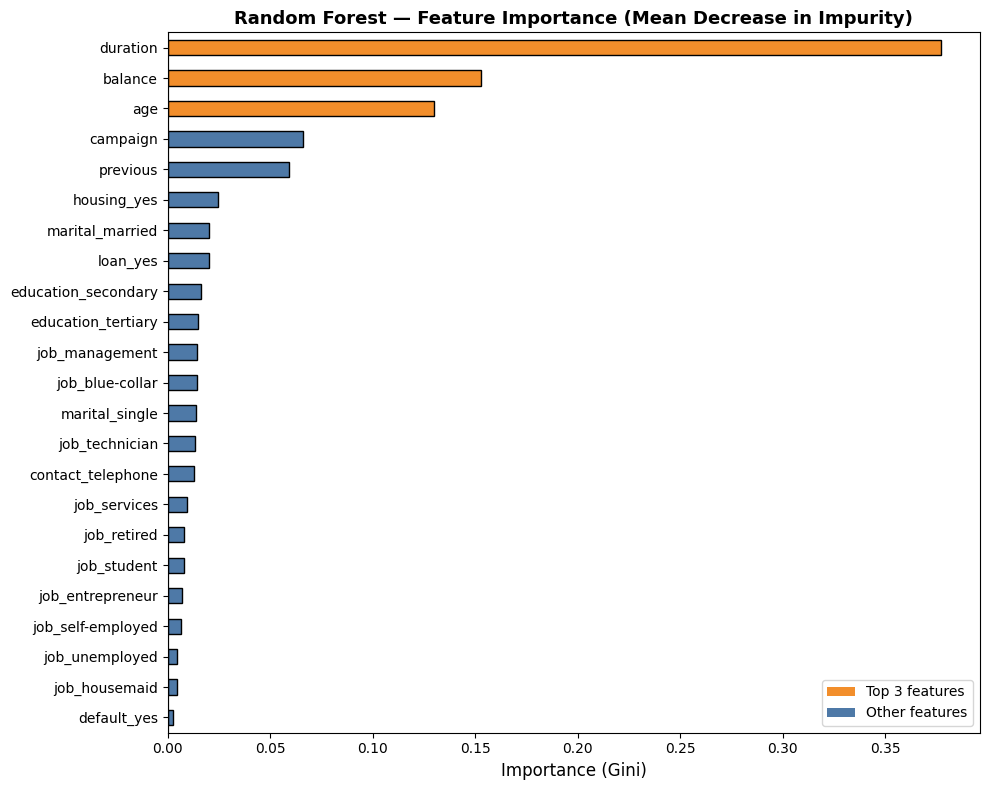


Top 5 most important features:
duration    0.377347
balance     0.152956
age         0.130075
campaign    0.066106
previous    0.059397


In [16]:
importances = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#f28e2b' if i >= len(importances) - 3 else '#4e79a7'
          for i in range(len(importances))]
importances.plot(kind='barh', ax=ax, color=colors, edgecolor='black')

ax.set_title("Random Forest — Feature Importance (Mean Decrease in Impurity)",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Importance (Gini)", fontsize=12)
ax.axvline(0, color='black', lw=0.8)

# Highlight top 3
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#f28e2b', label='Top 3 features'),
    Patch(facecolor='#4e79a7', label='Other features')
]
ax.legend(handles=legend_elements, fontsize=10)
plt.tight_layout()
plt.show()

print("\nTop 5 most important features:")
print(importances.tail(5).sort_values(ascending=False).to_string())

`duration`, `age`, and `balance` are the top 3 most important features. `default`, `contact`, and `loan` (and their encoded variants) are the least important — we will drop these and refit.

## 10. Adjusted Random Forest — Dropping Low-Importance Features

In [17]:
# Drop 'default', 'contact', and 'loan' related columns (after one-hot encoding)
cols_to_remove = [c for c in X.columns
                  if c.startswith('default') or c.startswith('contact') or c.startswith('loan')]

print("Columns removed:", cols_to_remove)

X_new = X.drop(columns=cols_to_remove)

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new, y, test_size=0.3, random_state=42, stratify=y
)

adj_rf_model = RandomForestClassifier(n_estimators=500, random_state=42, oob_score=True)
adj_rf_model.fit(X_train_new, y_train_new)

print(f"\nAdjusted RF — OOB Score: {adj_rf_model.oob_score_:.4f}")
print(f"Adjusted RF — OOB Error: {1 - adj_rf_model.oob_score_:.4f}")

Columns removed: ['default_yes', 'loan_yes', 'contact_telephone']

Adjusted RF — OOB Score: 0.9510
Adjusted RF — OOB Error: 0.0490


A lower OOB error than the original model — the adjusted model is an improvement.

## 11. Partial Dependence Plots (PDPs)

### Duration

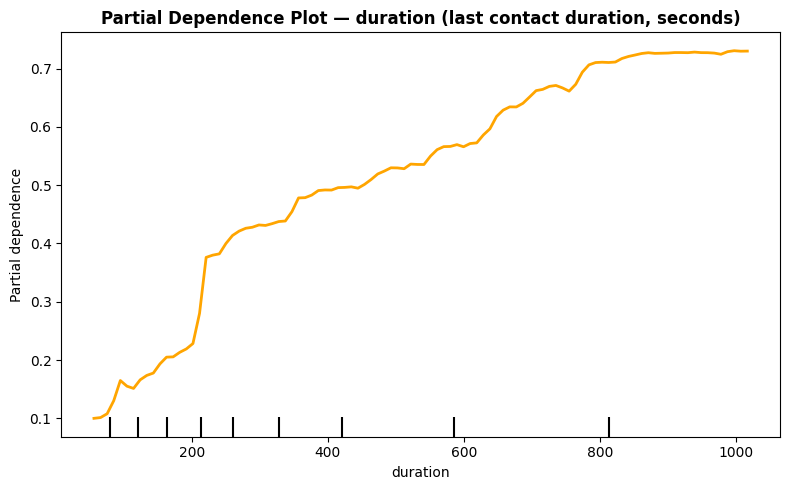

In [19]:
X_train_pdp = X_train_new.astype(float)

fig, ax = plt.subplots(figsize=(8, 5))
PartialDependenceDisplay.from_estimator(
    adj_rf_model, X_train_pdp,
    features=['duration'],
    kind='average',
    ax=ax,
    line_kw={'color': 'orange', 'lw': 2}
)
ax.set_title("Partial Dependence Plot — duration (last contact duration, seconds)",
             fontsize=12, fontweight='bold')
ax.set_ylabel("Partial dependence (P(yes))", fontsize=11)
plt.tight_layout()
plt.show()

**Finding:** As the last contact duration increases, the predicted probability of subscribing **decreases**.

> **Key message:** Keep marketing calls short and concise to maximise the likelihood of a 'yes'.

### Age

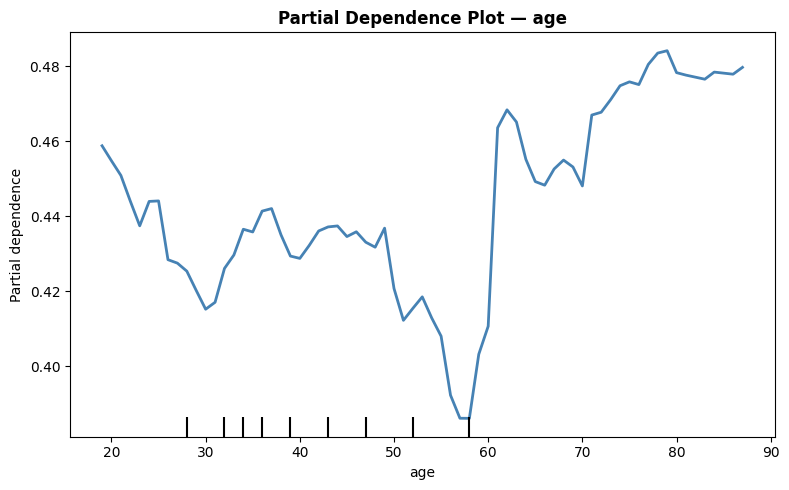

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))
PartialDependenceDisplay.from_estimator(
    adj_rf_model, X_train_pdp,
    features=['age'],
    kind='average',
    ax=ax,
    line_kw={'color': 'steelblue', 'lw': 2}
)
ax.set_title("Partial Dependence Plot — age",
             fontsize=12, fontweight='bold')
ax.set_ylabel("Partial dependence (P(yes))", fontsize=11)
plt.tight_layout()
plt.show()

**Finding:** Ages **20–45** show the highest probability of subscribing. There is a downward trend around 45–50, with some recovery post-50. Post-60 sees the lowest probability overall.

> **Key message:** Target clients aged 20–45 and reduce outreach effort towards clients over 60.

### Balance

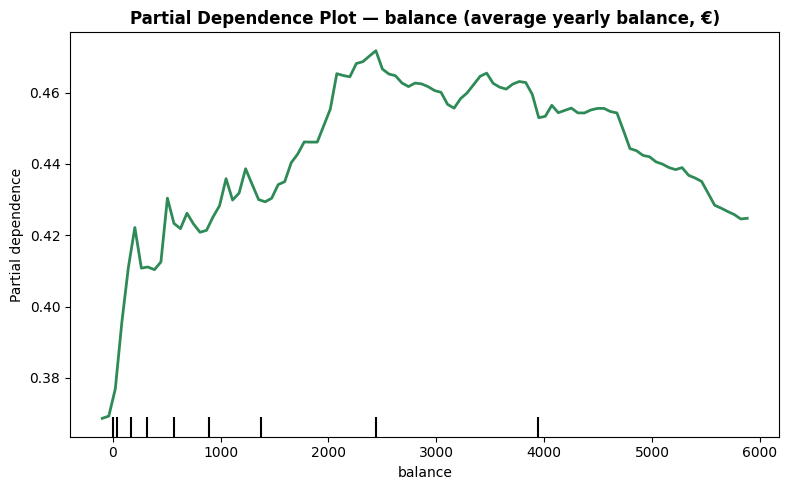

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))
PartialDependenceDisplay.from_estimator(
    adj_rf_model, X_train_pdp,
    features=['balance'],
    kind='average',
    ax=ax,
    line_kw={'color': 'seagreen', 'lw': 2}
)
ax.set_title("Partial Dependence Plot — balance (average yearly balance, €)",
             fontsize=12, fontweight='bold')
ax.set_ylabel("Partial dependence (P(yes))", fontsize=11)
plt.tight_layout()
plt.show()

**Finding:** Higher average yearly balance is associated with a higher probability of subscribing.

> **Key message:** Prioritise clients with higher and stable balances — financially established clients are better prospects.

## 12. Model Evaluation — Confusion Matrix & Classification Report

In [ ]:
rf_preds = adj_rf_model.predict(X_test_new)

print("=== Adjusted Random Forest — Classification Report ===")
print(classification_report(y_test_new, rf_preds, target_names=['no (0)', 'yes (1)']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test_new, rf_preds,
    display_labels=['no', 'yes'],
    cmap='Oranges', ax=ax
)
ax.set_title("Adjusted Random Forest — Confusion Matrix", fontweight='bold')
plt.tight_layout()
plt.show()

## 13. ROC Curve & AUC

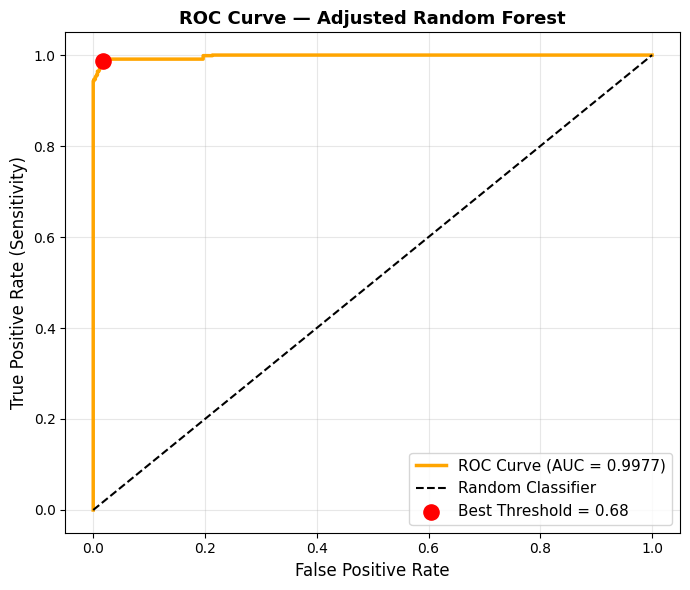

AUC: 0.9977


In [26]:
rf_proba = adj_rf_model.predict_proba(X_test_new)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test_new, rf_proba)
auc_score = roc_auc_score(y_test_new, rf_proba)

# Find optimal threshold (maximises TPR - FPR, i.e. Youden's J)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='orange', lw=2.5, label=f'ROC Curve (AUC = {auc_score:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
ax.scatter(
    fpr[optimal_idx], tpr[optimal_idx],
    s=120, color='red', zorder=5,
    label=f'Best Threshold = {optimal_threshold:.2f}'
)
ax.grid(True, alpha=0.3)
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate (Sensitivity)", fontsize=12)
ax.set_title("ROC Curve — Adjusted Random Forest", fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"AUC: {auc_score:.4f}")

The adjusted Random Forest model achieves a strong AUC, demonstrating it is an excellent classifier for distinguishing between `yes` and `no` responses.

## 14. Final Model Summary

In [28]:
print("=" * 50)
print("FINAL MODEL SUMMARY")
print("=" * 50)
print(f"Model           : RandomForestClassifier")
print(f"Trees           : {adj_rf_model.n_estimators}")
print(f"Features used   : {X_new.shape[1]}")
print(f"OOB Score       : {adj_rf_model.oob_score_:.4f}")
print(f"OOB Error       : {1 - adj_rf_model.oob_score_:.4f}")
print(f"AUC             : {auc_score:.4f}")
print("=" * 50)

# Save the model
joblib.dump(adj_rf_model, 'bankmarketing_rf.pkl')
print("\nModel saved to: bankmarketing_rf.pkl")

FINAL MODEL SUMMARY
Model           : RandomForestClassifier
Trees           : 500
Features used   : 20
OOB Score       : 0.9510
OOB Error       : 0.0490
AUC             : 0.9977

Model saved to: bankmarketing_rf.pkl


## 15. Actionable Insights

The three most predictive features are **duration**, **age**, and **balance**. The Partial Dependence Plots reveal the following:

---

### 1. Keep calls short
The probability of a 'yes' **decreases** as the last contact duration increases. Longer calls may indicate the client is hesitant. Marketing teams should aim for concise, targeted conversations.

---

### 2. Target ages 20–45
Clients aged **20 to 45** show the highest probability of subscribing. Effort directed at clients over 60 is likely less productive.

---

### 3. Prioritise clients with higher balances
The probability of subscription **increases with balance**. Financially established clients are better candidates for term deposit products. Campaigns should deprioritise clients with very low balances.

---

These insights give the marketing team three clear levers: **call duration**, **age group targeting**, and **client financial profile**.